In [11]:
# Célula 1: Instalação das bibliotecas (se você já tiver o pandas e o requests, será bem rápido)
!pip install requests pandas matplotlib seaborn mplsoccer

In [12]:
!pip install cloudscraper

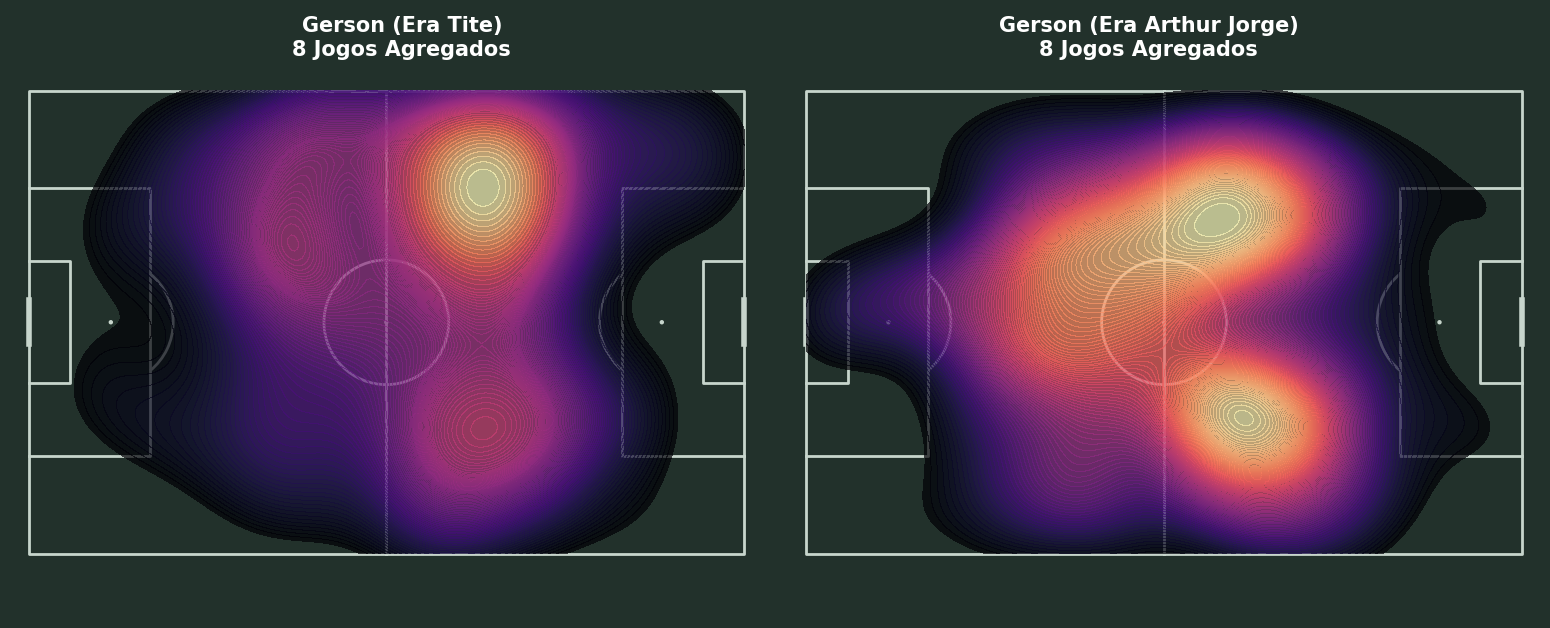

In [13]:
import os
import json
import matplotlib.pyplot as plt
import seaborn as sns
from mplsoccer import Pitch

# Função para extrair e agregar todas as coordenadas de uma pasta
def agregar_coordenadas_heatmap(pasta, sigla, jogador):
    pontos_x = []
    pontos_y = []
    
    for i in range(1, 9):
        caminho_arquivo = os.path.join(pasta, f"jogo{i}_{sigla}_{jogador}_heatmap.json")
        
        # Abre cada um dos 8 arquivos e extrai os pontos
        with open(caminho_arquivo, 'r', encoding='utf-8') as f:
            dados = json.load(f)
            # O Sofascore guarda os pontos dentro de uma lista chamada 'heatmap'
            for ponto in dados.get('heatmap', []):
                pontos_x.append(ponto['x'])
                pontos_y.append(ponto['y'])
                
    return pontos_x, pontos_y

# Extraindo os dados agregados do Gerson
x_tite, y_tite = agregar_coordenadas_heatmap('dados_tite', 'tt', 'gerson')
x_arthur, y_arthur = agregar_coordenadas_heatmap('dados_arthur', 'aj', 'gerson')

# ==========================================
# DESENHANDO OS CAMPOS LADO A LADO
# ==========================================

# Criando a figura com 2 campos (ncols=2)
pitch = Pitch(pitch_type='opta', pitch_color='#22312b', line_color='#c7d5cc')
fig, axs = pitch.grid(ncols=2, title_height=0.08, endnote_space=0, axis=False, figheight=7)
fig.set_facecolor('#22312b')

# 1. Plotando a Era Tite (Campo da Esquerda)
pitch.kdeplot(x_tite, y_tite, ax=axs['pitch'][0], cmap='magma', fill=True, levels=100, alpha=0.7)
axs['title'].text(0.25, 0.5, 'Gerson (Era Tite)\n8 Jogos Agregados', 
                  color='white', va='center', ha='center', fontsize=15, fontweight='bold')

# 2. Plotando a Era Arthur Jorge (Campo da Direita)
pitch.kdeplot(x_arthur, y_arthur, ax=axs['pitch'][1], cmap='magma', fill=True, levels=100, alpha=0.7)
axs['title'].text(0.75, 0.5, 'Gerson (Era Arthur Jorge)\n8 Jogos Agregados', 
                  color='white', va='center', ha='center', fontsize=15, fontweight='bold')

plt.show()

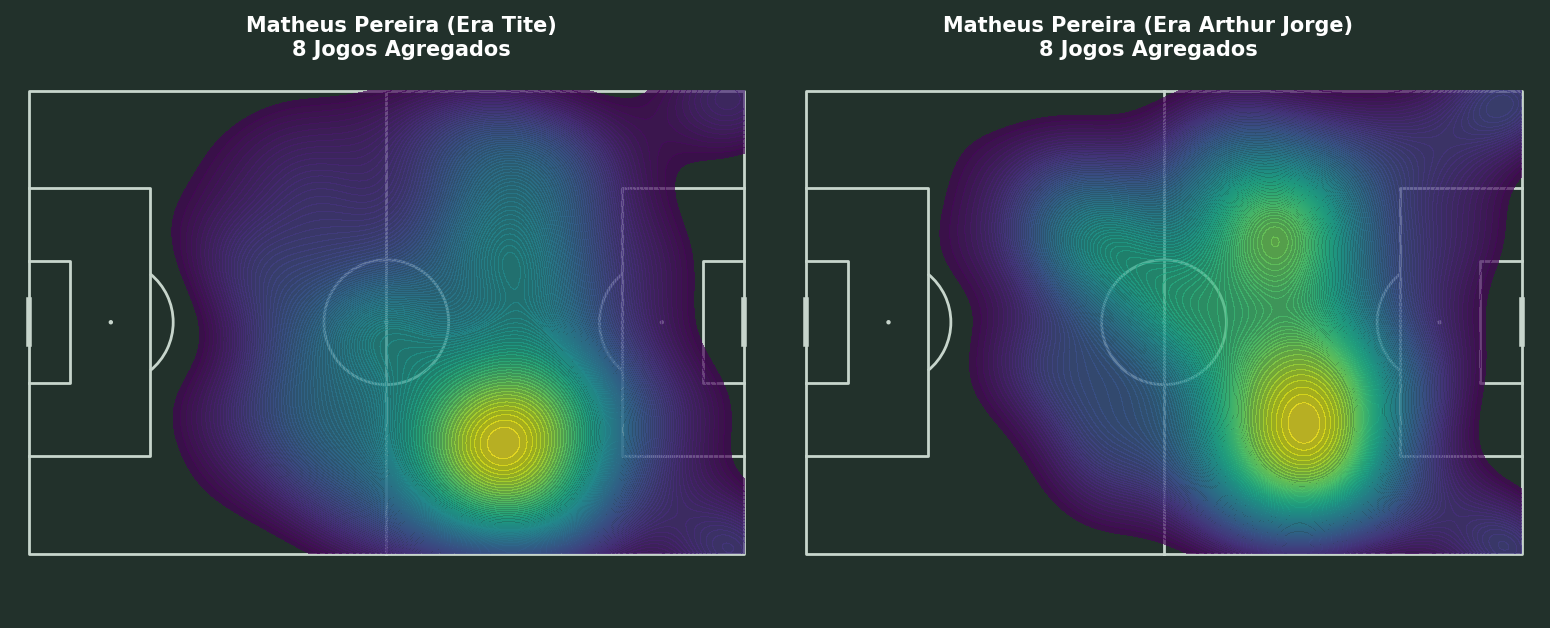

In [14]:
# ==========================================
# EXTRAINDO E DESENHANDO: MATHEUS PEREIRA
# ==========================================

# 1. Extraindo os dados agregados do Matheus Pereira usando a função anterior
x_tite_mp, y_tite_mp = agregar_coordenadas_heatmap('dados_tite', 'tt', 'matheus')
x_arthur_mp, y_arthur_mp = agregar_coordenadas_heatmap('dados_arthur', 'aj', 'matheus')

# 2. Criando a figura com 2 campos (ncols=2)
fig_mp, axs_mp = pitch.grid(ncols=2, title_height=0.08, endnote_space=0, axis=False, figheight=7)
fig_mp.set_facecolor('#22312b')

# 3. Plotando a Era Tite (Campo da Esquerda)
pitch.kdeplot(x_tite_mp, y_tite_mp, ax=axs_mp['pitch'][0], cmap='viridis', fill=True, levels=100, alpha=0.7)
axs_mp['title'].text(0.25, 0.5, 'Matheus Pereira (Era Tite)\n8 Jogos Agregados', 
                  color='white', va='center', ha='center', fontsize=15, fontweight='bold')

# 4. Plotando a Era Arthur Jorge (Campo da Direita)
pitch.kdeplot(x_arthur_mp, y_arthur_mp, ax=axs_mp['pitch'][1], cmap='viridis', fill=True, levels=100, alpha=0.7)
axs_mp['title'].text(0.75, 0.5, 'Matheus Pereira (Era Arthur Jorge)\n8 Jogos Agregados', 
                  color='white', va='center', ha='center', fontsize=15, fontweight='bold')

plt.show()

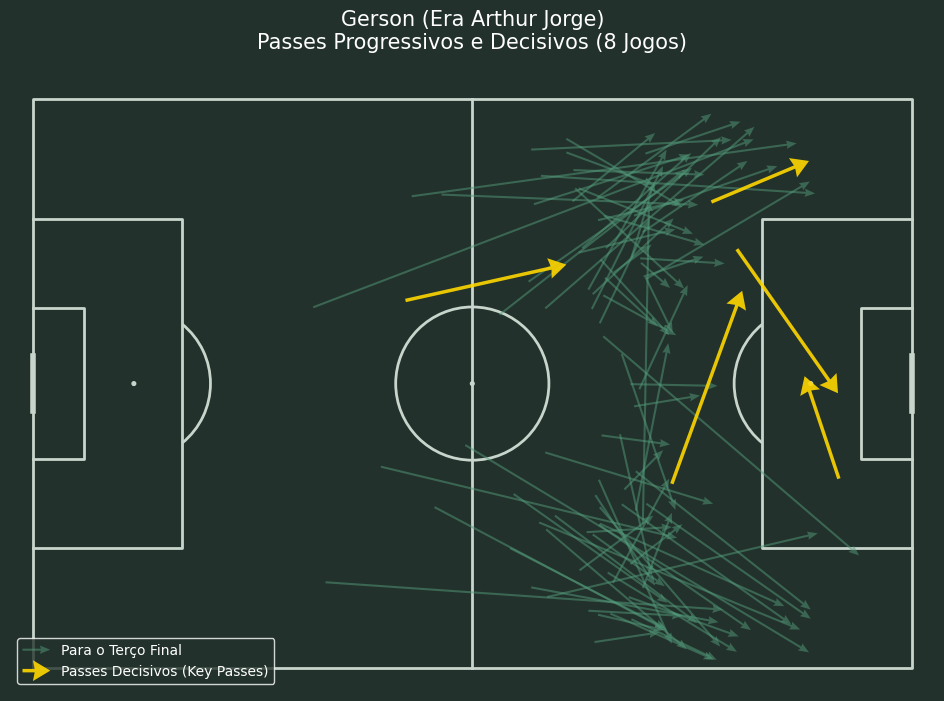

In [15]:
# ==========================================
# MAPA DE PASSES AGRESSIVOS: GERSON (ERA ARTHUR JORGE)
# ==========================================

def plotar_passes_verticais_gerson(pasta, sigla):
    fig, ax = pitch.draw(figsize=(10, 7))
    fig.set_facecolor('#22312b')
    
    passes_x_ini, passes_y_ini, passes_x_fim, passes_y_fim = [], [], [], []
    key_x_ini, key_y_ini, key_x_fim, key_y_fim = [], [], [], []
    
    for i in range(1, 9):
        caminho = os.path.join(pasta, f"jogo{i}_{sigla}_gerson_passes.json")
        if os.path.exists(caminho):
            with open(caminho, 'r', encoding='utf-8') as f:
                dados = json.load(f)
                
                for evento in dados.get('passes', []):
                    # Filtrar apenas passes que deram certo
                    if evento.get('outcome') == True:
                        x_ini = evento['playerCoordinates']['x']
                        y_ini = evento['playerCoordinates']['y']
                        x_fim = evento['passEndCoordinates']['x']
                        y_fim = evento['passEndCoordinates']['y']
                        
                        # Destacar Passes Decisivos (Key Passes)
                        if evento.get('keypass') == True:
                            key_x_ini.append(x_ini)
                            key_y_ini.append(y_ini)
                            key_x_fim.append(x_fim)
                            key_y_fim.append(y_fim)
                        # Filtrar passes que quebram linhas para o terço final (X final > 70)
                        elif x_fim > 70 and x_ini < 70:
                            passes_x_ini.append(x_ini)
                            passes_y_ini.append(y_ini)
                            passes_x_fim.append(x_fim)
                            passes_y_fim.append(y_fim)

    # Plotando passes progressivos (Verdes, mais transparentes)
    pitch.arrows(passes_x_ini, passes_y_ini, passes_x_fim, passes_y_fim,
                 ax=ax, width=1.5, headwidth=4, color='#539b7c', alpha=0.5, label='Para o Terço Final')
    
    # Plotando Passes Decisivos (Dourados, grossos e em destaque)
    pitch.arrows(key_x_ini, key_y_ini, key_x_fim, key_y_fim,
                 ax=ax, width=2.5, headwidth=6, color='#ffd700', alpha=0.9, label='Passes Decisivos (Key Passes)')
    
    ax.legend(facecolor='#22312b', edgecolor='white', labelcolor='white', loc='lower left')
    plt.title('Gerson (Era Arthur Jorge)\nPasses Progressivos e Decisivos (8 Jogos)', color='white', size=15, pad=20)
    plt.show()

# Chamando a função para a Era Arthur Jorge
plotar_passes_verticais_gerson('dados_arthur', 'aj')

In [16]:
import pandas as pd

def calcular_medias_p90(pasta, sigla, nome_busca):
    total_minutos = 0
    total_toques = 0
    total_keypasses = 0
    total_passes = 0
    
    for i in range(1, 9):
        caminho = os.path.join(pasta, f"jogo{i}_{sigla}_lineups.json")
        if os.path.exists(caminho):
            with open(caminho, 'r', encoding='utf-8') as f:
                dados = json.load(f)
                
                # Junta os jogadores dos dois times para buscar
                jogadores = dados['home']['players'] + dados['away']['players']
                
                for j in jogadores:
                    # Busca o jogador pelo nome ignorando maiúsculas
                    if nome_busca.lower() in j['player']['name'].lower():
                        stats = j.get('statistics', {})
                        total_minutos += stats.get('minutesPlayed', 0)
                        total_toques += stats.get('touches', 0)
                        total_keypasses += stats.get('keyPass', 0)
                        total_passes += stats.get('accuratePass', 0)
                        
    # Calculando a métrica p90 (por 90 minutos)
    if total_minutos > 0:
        toques_p90 = round((total_toques / total_minutos) * 90, 2)
        keypasses_p90 = round((total_keypasses / total_minutos) * 90, 2)
        passes_p90 = round((total_passes / total_minutos) * 90, 2)
    else:
        toques_p90 = keypasses_p90 = passes_p90 = 0
        
    return [toques_p90, passes_p90, keypasses_p90]

# Jogadores que vamos analisar
jogadores = ['Gerson', 'Matheus Pereira', 'Kaio Jorge']
resultados = []

for jogador in jogadores:
    # Coletando Era Tite
    stats_tite = calcular_medias_p90('dados_tite', 'tt', jogador)
    # Coletando Era Arthur Jorge
    stats_arthur = calcular_medias_p90('dados_arthur', 'aj', jogador)
    
    resultados.append({
        'Jogador': jogador,
        'Toques p90 (Tite)': stats_tite[0],
        'Toques p90 (Arthur)': stats_arthur[0],
        'Passes Certos p90 (Tite)': stats_tite[1],
        'Passes Certos p90 (Arthur)': stats_arthur[1],
        'Passes Decisivos p90 (Tite)': stats_tite[2],
        'Passes Decisivos p90 (Arthur)': stats_arthur[2]
    })

# Exibindo a tabela final
df_final = pd.DataFrame(resultados)
display(df_final)

,Jogador,Toques p90 (Tite),Toques p90 (Arthur),Passes Certos p90 (Tite),Passes Certos p90 (Arthur),Passes Decisivos p90 (Tite),Passes Decisivos p90 (Arthur)
0,Gerson,69.65,87.01,48.64,64.34,1.16,0.81
1,Matheus Pereira,64.69,67.09,36.96,36.66,2.68,3.69
2,Kaio Jorge,26.93,28.07,12.70,15.52,1.31,1.49


In [17]:
import pandas as pd
import json
import os

def calcular_totais_absolutos(pasta, sigla, nome_busca):
    total_minutos = 0
    total_toques = 0
    total_keypasses = 0
    total_passes = 0
    
    for i in range(1, 9):
        caminho = os.path.join(pasta, f"jogo{i}_{sigla}_lineups.json")
        if os.path.exists(caminho):
            with open(caminho, 'r', encoding='utf-8') as f:
                dados = json.load(f)
                
                # Junta os jogadores dos dois times para buscar
                jogadores = dados['home']['players'] + dados['away']['players']
                
                for j in jogadores:
                    # Busca o jogador pelo nome ignorando maiúsculas
                    if nome_busca.lower() in j['player']['name'].lower():
                        stats = j.get('statistics', {})
                        total_minutos += stats.get('minutesPlayed', 0)
                        total_toques += stats.get('touches', 0)
                        total_keypasses += stats.get('keyPass', 0)
                        total_passes += stats.get('accuratePass', 0)
                        
    return [total_minutos, total_toques, total_passes, total_keypasses]

# Jogadores que vamos analisar
jogadores = ['Gerson', 'Matheus Pereira', 'Kaio Jorge']
resultados_absolutos = []

for jogador in jogadores:
    # Coletando totais absolutos Era Tite
    stats_tite = calcular_totais_absolutos('dados_tite', 'tt', jogador)
    # Coletando totais absolutos Era Arthur Jorge
    stats_arthur = calcular_totais_absolutos('dados_arthur', 'aj', jogador)
    
    resultados_absolutos.append({
        'Jogador': jogador,
        'Minutos (Tite)': stats_tite[0],
        'Minutos (Arthur)': stats_arthur[0],
        'Key Passes (Tite)': stats_tite[3],
        'Key Passes (Arthur)': stats_arthur[3],
        'Passes Certos (Tite)': stats_tite[2],
        'Passes Certos (Arthur)': stats_arthur[2],
        'Toques (Tite)': stats_tite[1],
        'Toques (Arthur)': stats_arthur[1]
    })

# Exibindo a tabela de números brutos
df_absolutos = pd.DataFrame(resultados_absolutos)
display(df_absolutos)

,Jogador,Minutos (Tite),Minutos (Arthur),Key Passes (Tite),Key Passes (Arthur),Passes Certos (Tite),Passes Certos (Arthur),Toques (Tite),Toques (Arthur)
0,Gerson,544,663,7,6,294,474,421,641
1,Matheus Pereira,672,707,20,29,276,288,483,527
2,Kaio Jorge,411,545,6,9,58,94,123,170
